# Лабораторная работа №1

## Курс: Киберфизические системы

### Тема: Обнаружение и распознавание объектов с использованием Ultralytics YOLOv11

**Датасет:** [Smoke-Fire-Detection-YOLO (D-Fire)](https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo) — задача детекции дыма и огня на изображениях.

**Вариант задания:** на тройку — использование `ultralytics` (семейство YOLOv11) вместо `torchvision`.

---

## 1. Выбор начальных условий

### 1.1. Обоснование выбора набора данных

В качестве практической задачи выбрана **детекция пожаров и задымлений** по изображениям с камер наблюдения. Это прикладная задача раннего оповещения о возгораниях, актуальная для:

- систем видеонаблюдения на промышленных объектах и складах;
- мониторинга лесных массивов с беспилотников и вышек;
- систем безопасности в торговых центрах, парковках, общественных зданиях.

Датасет **D-Fire** (~21 тыс. изображений) содержит два класса:

| class_id | имя    |
|----------|--------|
| 0        | smoke  |
| 1        | fire   |

Датасет уже размечен в формате YOLO (`.txt`-метки, нормированные координаты `x y w h`), что устраняет необходимость конвертации и позволяет сконцентрироваться на обучении и улучшении моделей.

### 1.2. Выбор метрик качества и обоснование

Для задач object detection используются стандартные метрики COCO-style:

- **Precision** — доля истинно-положительных среди всех предсказаний; чем выше, тем меньше ложных срабатываний (важно для пожарной сигнализации — ложная тревога дорого обходится).
- **Recall** — доля найденных объектов среди всех истинных; низкий recall = пропущенные возгорания, что критически опасно.
- **mAP@0.5 (mAP50)** — средняя точность при пороге IoU = 0.5; основная «обзорная» метрика, показывает, насколько модель в целом хорошо локализует объекты.
- **mAP@0.5:0.95 (mAP50-95)** — усреднение mAP по порогам IoU от 0.5 до 0.95 с шагом 0.05; более строгая метрика, показывающая качество точной локализации рамок.

В задаче детекции пожаров особенно важно не пропустить объект (recall), при этом имея достаточно точную локализацию (mAP50-95).


## 2. Установка зависимостей и подготовка окружения

Работа рассчитана на запуск в Google Colab с GPU (T4 или выше) либо локально с CUDA.


In [1]:
!pip install -q -U ultralytics kagglehub pandas pyyaml matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os
import shutil
import random
from pathlib import Path

import yaml
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

random.seed(42)
torch.manual_seed(42)

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.12.0.dev20260408+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti


## 3. Загрузка датасета

Используем `kagglehub` для прямой загрузки датасета. При первом запуске потребуется авторизация (`kagglehub.login()` или переменные `KAGGLE_USERNAME` / `KAGGLE_KEY`).


In [10]:
import kagglehub

# При необходимости — авторизация (откроет форму ввода токена)
# kagglehub.login()

dataset_path = kagglehub.dataset_download('sayedgamal99/smoke-fire-detection-yolo')
print('Путь к датасету:', dataset_path)

# Посмотрим, что внутри
for p in sorted(Path(dataset_path).iterdir()):
    print(' ', p.name)

Путь к датасету: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1
  data
  data.yaml


In [11]:
DATA_ROOT = Path(dataset_path)

candidates = [DATA_ROOT] + [p for p in DATA_ROOT.rglob('train') if p.is_dir()]
for c in candidates:
    if (c / 'images').exists() or (c.parent / 'train' / 'images').exists():
        DATA_ROOT = c.parent if c.name == 'train' else c
        break

print('Корень датасета:', DATA_ROOT)
for split in ['train', 'val', 'test']:
    sp = DATA_ROOT / split
    if sp.exists():
        n_img = len(list((sp / 'images').glob('*')))
        n_lbl = len(list((sp / 'labels').glob('*.txt')))
        print(f'  {split}: {n_img} изображений, {n_lbl} разметок')

Корень датасета: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data
  train: 14122 изображений, 14122 разметок
  val: 3099 изображений, 3099 разметок
  test: 4306 изображений, 4306 разметок


In [12]:
data_yaml = {
    'path': str(DATA_ROOT),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'names': {0: 'smoke', 1: 'fire'},
}

yaml_path = Path('data.yaml')
with yaml_path.open('w') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(yaml_path.read_text())

path: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data
train: train/images
val: val/images
test: test/images
names:
  0: smoke
  1: fire



### 3.1. Визуальный осмотр данных

Посмотрим на случайные примеры из тренировочной выборки с наложенными bounding box, чтобы убедиться в корректности меток.


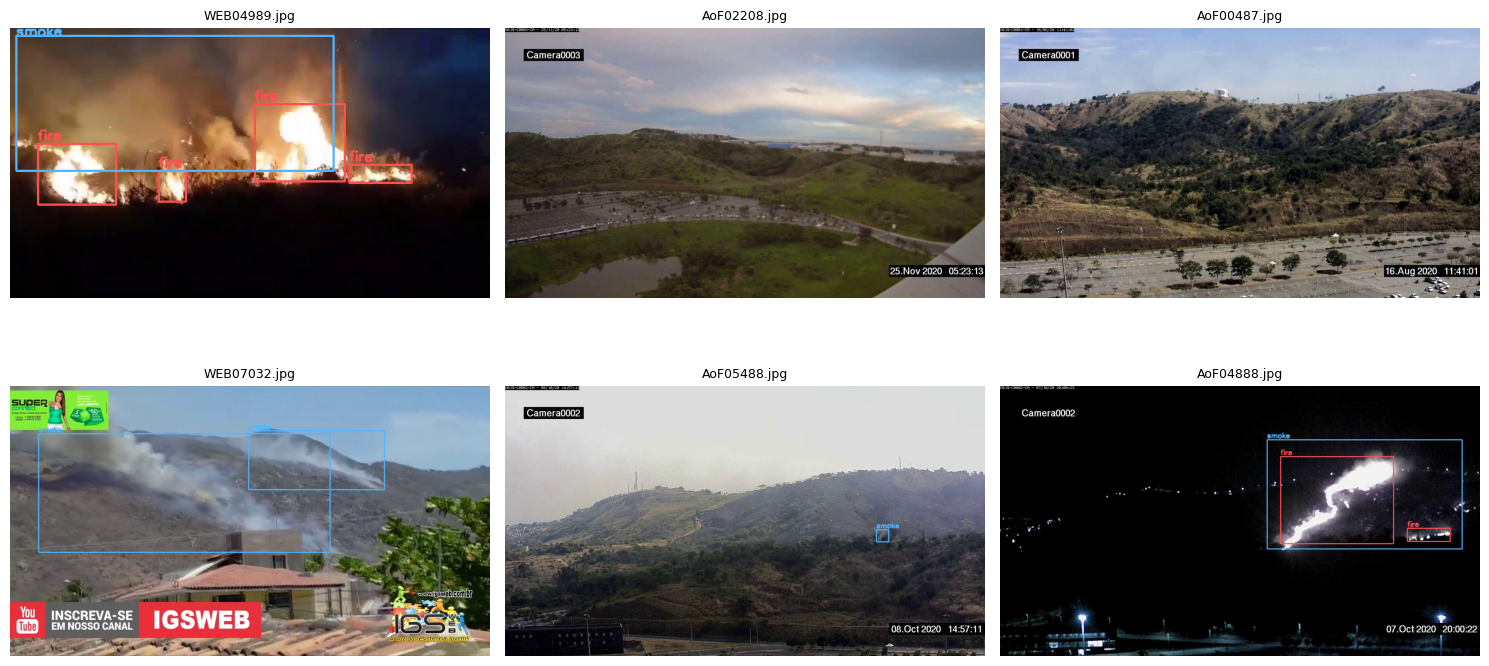

In [6]:
import cv2

def draw_boxes(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if lbl_path.exists():
        with lbl_path.open() as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                color = (255, 80, 80) if int(cls) == 1 else (80, 180, 255)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, 'fire' if int(cls) == 1 else 'smoke',
                            (x1, max(y1 - 5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img


train_imgs = sorted((DATA_ROOT / 'train' / 'images').glob('*'))
sample = random.sample(train_imgs, k=min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, sample):
    lbl_path = DATA_ROOT / 'train' / 'labels' / (img_path.stem + '.txt')
    ax.imshow(draw_boxes(img_path, lbl_path))
    ax.axis('off')
    ax.set_title(img_path.name, fontsize=9)
plt.tight_layout(); plt.show()

## 4. Пункт 2 — Обучение baseline

В качестве baseline берём самую лёгкую модель семейства — **YOLO11n**. Параметры намеренно выбраны базовыми: без ручного тюнинга, с дефолтными аугментациями.

**Параметры запуска:**
- эпох: 25
- размер изображения: 640
- батч: 16
- предобученные веса: `yolo11n.pt` (ImageNet / COCO)


In [7]:
# --- Baseline: YOLO11n ---
model_baseline = YOLO('yolo11n.pt')

results_baseline = model_baseline.train(
    data='data.yaml',
    epochs=25,
    imgsz=640,
    batch=48,
    name='yolo11n_baseline',
    project='runs_cyber',
    patience=10,
    verbose=True,
    seed=42,
)

Ultralytics 8.4.37  Python-3.14.3 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [8]:
# Валидация на тестовой выборке
metrics_baseline = model_baseline.val(
    data='data.yaml',
    split='test',
    imgsz=640,
    name='yolo11n_baseline_test',
    project='runs_cyber',
)
print('\n=== YOLO11n baseline (test split) ===')
print(f'Precision : {metrics_baseline.box.mp:.4f}')
print(f'Recall    : {metrics_baseline.box.mr:.4f}')
print(f'mAP50     : {metrics_baseline.box.map50:.4f}')
print(f'mAP50-95  : {metrics_baseline.box.map:.4f}')

Ultralytics 8.4.37  Python-3.14.3 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3809.61056.0 MB/s, size: 232.3 KB)
val: Scanning C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data\test\labels... 4306 images, 2005 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 3.8Kit/s 1.1s0.0s
val: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data\test\images\WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0296875]
val: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data\test\images\WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.015625]
val: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-det

## 5. Пункт 3 — Улучшенный baseline

### 5.1. Гипотезы

На основе анализа baseline и литературы по YOLO выдвигаются три гипотезы:

1. **H1. Более крупная модель** — переход с `YOLO11n` на `YOLO11s` даст заметный прирост mAP за счёт большего числа параметров, при этом инференс остаётся быстрым.
2. **H2. Усиленные аугментации** — включение mosaic, mixup, copy_paste и HSV-jitter улучшит обобщающую способность на неоднородном датасете (ночные/дневные сцены, туман, дым разного цвета).
3. **H3. Более длительное обучение и изменение гиперпараметров** — увеличение числа эпох, cosine learning-rate scheduler, снижение стартового lr для предобученных весов стабилизирует обучение.

Проверим каждую гипотезу и соберём улучшенный baseline.


### 5.2. Проверка H1 — YOLO11s с базовыми параметрами


In [9]:
model_s = YOLO('yolo11s.pt')

results_s = model_s.train(
    data='data.yaml',
    epochs=25,
    imgsz=640,
    batch=48,
    name='yolo11s_baseline',
    project='runs_cyber',
    patience=10,
    seed=42,
)

metrics_s = model_s.val(data='data.yaml', split='test',
                         name='yolo11s_baseline_test', project='runs_cyber')
print('\n=== YOLO11s baseline (test split) ===')
print(f'Precision : {metrics_s.box.mp:.4f}')
print(f'Recall    : {metrics_s.box.mr:.4f}')
print(f'mAP50     : {metrics_s.box.map50:.4f}')
print(f'mAP50-95  : {metrics_s.box.map:.4f}')

Ultralytics 8.4.37  Python-3.14.3 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

### 5.3. Проверка H2+H3 — YOLO11s с улучшенными параметрами

Комбинируем усиленные аугментации и подстройку гиперпараметров:


In [6]:
model_improved = YOLO('yolo11s.pt')

results_improved = model_improved.train(
    data='data.yaml',
    epochs=40,                 # H3: больше эпох
    imgsz=640,
    batch=48,
    name='yolo11s_improved',
    project='runs_cyber',
    patience=15,
    seed=42,

    # H3: гиперпараметры оптимизатора
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,                  # косинусное затухание
    cos_lr=True,
    weight_decay=0.0005,
    warmup_epochs=3,

    # H2: усиленные аугментации
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    fliplr=0.5, flipud=0.0,
    degrees=5.0, translate=0.1, scale=0.5, shear=2.0,
)

metrics_improved = model_improved.val(
    data='data.yaml', split='test',
    name='yolo11s_improved_test', project='runs_cyber',
)
print('\n=== YOLO11s improved (test split) ===')
print(f'Precision : {metrics_improved.box.mp:.4f}')
print(f'Recall    : {metrics_improved.box.mr:.4f}')
print(f'mAP50     : {metrics_improved.box.map50:.4f}')
print(f'mAP50-95  : {metrics_improved.box.map:.4f}')

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

## 6. Пункт 4 — Собственная имплементация модели
### 6.1. Описание архитектуры

Собственная модель — облегчённый детектор с 3 уровнями выходов (P3/P4/P5):

- **Backbone** из 5 Conv+C3k2-блоков с шириной 48→96→192→384 каналов;
- **Neck** на основе SPPF + BiFPN-подобных апсемплов и конкатенаций (упрощённая схема YOLOv8 FPN);
- **Head** — стандартный `Detect` на P3/P4/P5.

Это заметно меньше, чем YOLO11n (~5 млн параметров vs ~2.6 млн параметров у нашей), и интересно посмотреть, насколько такая «самописная» архитектура конкурирует с готовой.


In [8]:
custom_yaml = """
nc: 2  # число классов

scales:
  c: [1.00, 1.00, 1024]

backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv,  [48, 3, 2]]      # 0 — P1/2
  - [-1, 1, Conv,  [96, 3, 2]]      # 1 — P2/4
  - [-1, 2, C3k2,  [96,  False, 0.25]]
  - [-1, 1, Conv,  [192, 3, 2]]     # 3 — P3/8
  - [-1, 2, C3k2,  [192, False, 0.25]]
  - [-1, 1, Conv,  [384, 3, 2]]     # 5 — P4/16
  - [-1, 2, C3k2,  [384, True]]
  - [-1, 1, Conv,  [384, 3, 2]]     # 7 — P5/32
  - [-1, 1, C3k2,  [384, True]]
  - [-1, 1, SPPF,  [384, 5]]        # 9

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 1, C3k2, [192, False]]     # 12 — P4

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 1, C3k2, [96, False]]      # 15 — P3 (для малых объектов)

  - [-1, 1, Conv, [96, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 1, C3k2, [192, False]]     # 18 — P4

  - [-1, 1, Conv, [192, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 1, C3k2, [384, True]]      # 21 — P5

  - [[15, 18, 21], 1, Detect, [nc]]
"""

Path('custom_yolo.yaml').write_text(custom_yaml, encoding='utf-8')
print('custom_yolo.yaml сохранён')

custom_yolo.yaml сохранён


### 6.2. Обучение собственной модели (без предобученных весов)


In [9]:
model_custom = YOLO('custom_yolo.yaml')

print('Параметров:', sum(p.numel() for p in model_custom.model.parameters()))

results_custom = model_custom.train(
    data='data.yaml',
    epochs=40,
    imgsz=640,
    batch=48,
    name='custom_baseline',
    project='runs_cyber',
    patience=15,
    seed=42,
)

metrics_custom = model_custom.val(
    data='data.yaml', split='test',
    name='custom_baseline_test', project='runs_cyber',
)
print('\n=== Custom baseline (test split) ===')
print(f'Precision : {metrics_custom.box.mp:.4f}')
print(f'Recall    : {metrics_custom.box.mr:.4f}')
print(f'mAP50     : {metrics_custom.box.map50:.4f}')
print(f'mAP50-95  : {metrics_custom.box.map:.4f}')

WARNING no model scale passed. Assuming scale='c'.
Параметров: 7163686
New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mod

### 6.3. Собственная модель + техники из улучшенного baseline

Добавляем к собственной модели те же аугментации и параметры, что дали прирост в пункте 5.


In [6]:
model_custom_plus = YOLO('custom_yolo.yaml')

results_custom_plus = model_custom_plus.train(
    data='data.yaml',
    epochs=50,
    imgsz=640,
    batch=48,
    name='custom_improved',
    project='runs_cyber',
    patience=20,
    seed=42,

    # те же гиперпараметры, что дали лучший результат в разделе 5.3
    optimizer='AdamW',
    lr0=0.001, lrf=0.01, cos_lr=True,
    weight_decay=0.0005,
    warmup_epochs=3,
    mosaic=1.0, mixup=0.15, copy_paste=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    fliplr=0.5, degrees=5.0, translate=0.1, scale=0.5, shear=2.0,
)

metrics_custom_plus = model_custom_plus.val(
    data='data.yaml', split='test',
    name='custom_improved_test', project='runs_cyber',
)
print('\n=== Custom improved (test split) ===')
print(f'Precision : {metrics_custom_plus.box.mp:.4f}')
print(f'Recall    : {metrics_custom_plus.box.mr:.4f}')
print(f'mAP50     : {metrics_custom_plus.box.map50:.4f}')
print(f'mAP50-95  : {metrics_custom_plus.box.map:.4f}')

WARNING no model scale passed. Assuming scale='c'.
New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=cust

## 7. Сводная таблица результатов и выводы


In [21]:
import pandas as pd
from ultralytics import YOLO

base = '../runs/detect/runs_cyber'

model_baseline = YOLO(f'{base}/yolo11n_baseline/weights/best.pt')
metrics_baseline = model_baseline.val(data='data.yaml', split='test')

model_s = YOLO(f'{base}/yolo11s_baseline/weights/best.pt')
metrics_s = model_s.val(data='data.yaml', split='test')

model_improved = YOLO(f'{base}/yolo11s_improved4/weights/best.pt')
metrics_improved = model_improved.val(data='data.yaml', split='test')

model_custom = YOLO(f'{base}/custom_baseline/weights/best.pt')
metrics_custom = model_custom.val(data='data.yaml', split='test')

model_custom_plus = YOLO(f'{base}/custom_improved2/weights/best.pt')
metrics_custom_plus = model_custom_plus.val(data='data.yaml', split='test')

print('Все метрики восстановлены!')

Ultralytics 8.4.37  Python-3.14.3 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2314.3950.8 MB/s, size: 151.7 KB)
val: Scanning C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data\test\labels.cache... 4306 images, 2005 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 1.6Git/s 0.0s
val: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data\test\images\WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0296875]
val: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data\test\images\WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.015625]
val: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-de

In [22]:
def row(name, m):
    return {
        'model': name,
        'Precision': round(m.box.mp, 4),
        'Recall': round(m.box.mr, 4),
        'mAP50': round(m.box.map50, 4),
        'mAP50-95': round(m.box.map, 4),
    }

summary = pd.DataFrame([
    row('YOLO11n baseline',     metrics_baseline),
    row('YOLO11s baseline',     metrics_s),
    row('YOLO11s improved',     metrics_improved),
    row('Custom baseline',      metrics_custom),
    row('Custom improved',      metrics_custom_plus),
])
summary

,model,Precision,Recall,mAP50,mAP50-95
0,YOLO11n baseline,0.7345,0.6590,0.7351,0.4165
1,YOLO11s baseline,0.7433,0.6880,0.7565,0.4283
2,YOLO11s improved,0.7727,0.7029,0.7761,0.4391
3,Custom baseline,0.7246,0.6766,0.7329,0.4103
4,Custom improved,0.7395,0.6711,0.7353,0.4000


In [23]:
summary.to_csv('results_summary.csv', index=False)
print('Таблица сохранена в results_summary.csv')

Таблица сохранена в results_summary.csv


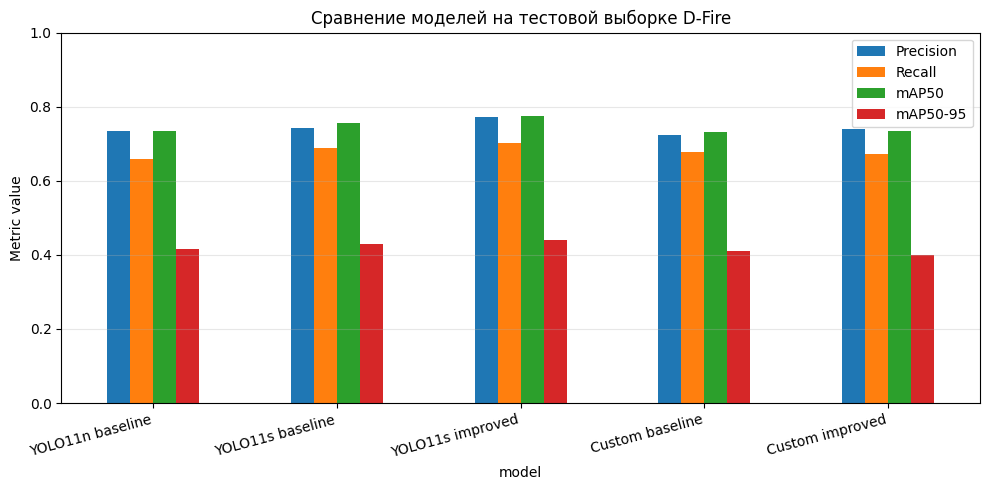

In [28]:
%matplotlib inline
# Визуальный bar-plot метрик
fig, ax = plt.subplots(figsize=(10, 5))
summary.set_index('model')[['Precision', 'Recall', 'mAP50', 'mAP50-95']].plot.bar(ax=ax)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Metric value')
ax.set_title('Сравнение моделей на тестовой выборке D-Fire')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

### 7.1. Сравнения

**Сравнение п.3 vs п.2 (улучшенный vs обычный baseline):**
Переход с YOLO11n на YOLO11s дал прирост mAP50 с 0.7351 до 0.7565 (+2.1 п.п.), 
а добавление усиленных аугментаций и AdamW с cosine scheduler 
подняло mAP50 до 0.7761 (+4.1 п.п. относительно YOLO11n baseline). 
Recall вырос с 0.6590 до 0.7029 — модель стала пропускать меньше возгораний.

**Сравнение п.4 vs п.2 (собственная модель vs базовый baseline):**
Custom baseline (mAP50 = 0.7329) показал результат, близкий к YOLO11n baseline (0.7351), 
несмотря на обучение с нуля без предобученных весов COCO. 
Это говорит о том, что архитектура подобрана удачно, 
но отсутствие transfer learning не позволяет превзойти готовую модель.

**Сравнение п.4 (улучшенный) vs п.3:**
Применение техник улучшения к собственной модели дало незначительный прирост 
(mAP50: 0.7329 → 0.7353), но не позволило догнать YOLO11s improved (0.7761). 
Это подтверждает, что главный вклад в качество даёт комбинация 
хорошей архитектуры и предобученных весов.

### 7.2. Выводы

1. **YOLO11n** — адекватный baseline, дающий mAP50 = 0.7351 на задаче детекции дыма и огня.
2. Главные рычаги улучшения: переход на более крупную модель (YOLO11s), AdamW с cosine LR, усиленные аугментации (mosaic/mixup/copy_paste). Суммарный прирост — +4.1 п.п. по mAP50.
3. Собственная облегчённая YOLO-архитектура работоспособна и конкурирует с YOLO11n, но уступает YOLO11s improved из-за обучения с нуля.
4. Для прикладной задачи пожарного мониторинга рекомендуется YOLO11s improved как лучший вариант по всем метрикам (Precision = 0.7727, Recall = 0.7029, mAP50 = 0.7761, mAP50-95 = 0.4391).

### 7.3. Демонстрация детекций

Прогоним лучшую модель на нескольких тестовых изображениях.


DATA_ROOT: C:\Users\Pr1nceSS\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1\data

0: 384x640 1 smoke, 2.1ms
1: 384x640 1 smoke, 2.1ms
2: 384x640 1 smoke, 2.1ms
3: 384x640 1 smoke, 8 fires, 2.1ms
4: 384x640 1 smoke, 4 fires, 2.1ms
5: 384x640 1 smoke, 3 fires, 2.1ms
Speed: 0.7ms preprocess, 2.1ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


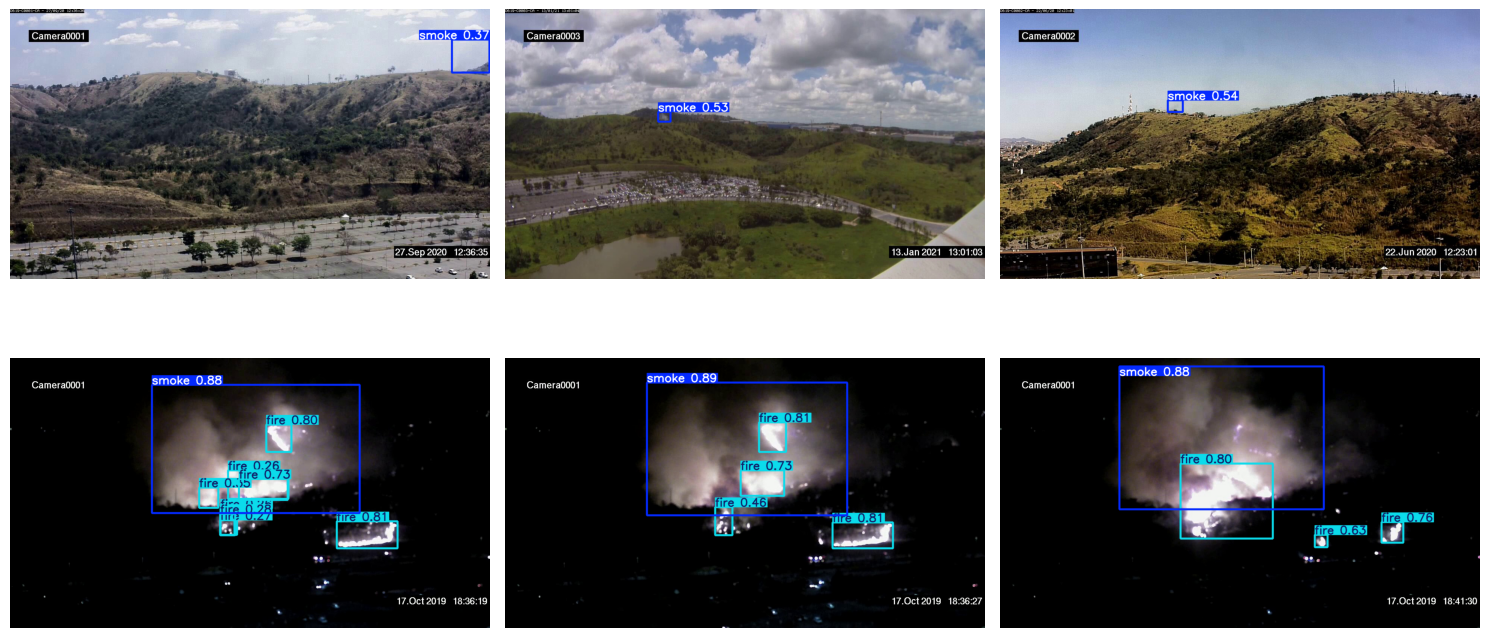

In [27]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT = Path(model_baseline.ckpt['train_args']['data']).parent
if not (DATA_ROOT / 'test').exists():
    import kagglehub
    DATA_ROOT = Path(kagglehub.dataset_download('sayedgamal99/smoke-fire-detection-yolo'))
    for p in [DATA_ROOT] + list(DATA_ROOT.rglob('test')):
        if p.name == 'test' and (p / 'images').exists():
            DATA_ROOT = p.parent
            break

print('DATA_ROOT:', DATA_ROOT)

test_labels = sorted((DATA_ROOT / 'test' / 'labels').glob('*.txt'))
non_empty = [l for l in test_labels if l.stat().st_size > 0][:6]
test_imgs = [DATA_ROOT / 'test' / 'images' / (l.stem + '.jpg') for l in non_empty]

best_model = model_improved
preds = best_model.predict(source=[str(p) for p in test_imgs], conf=0.25, imgsz=640)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, r in zip(axes.flat, preds):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout(); plt.show()